In [1]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def grid_R(NR, dR):
    R = np.zeros(NR)
    l = 10 / dR
    for i in range(NR):
        if i * dR < 10:
            R[i] = i * dR
        else:
            R[i] = 10** ((i + l ) / 2 / l)
    return R
def grid_Z(NZ, dZ):
    Z = np.zeros(NZ)
    l = 1 / dZ
    for i in range(NZ):
        if i * dZ < 1:
            Z[i] = i * dZ
        else:
            Z[i] = 10** ((i - l) / l)
    return Z
R = grid_R(381,0.1)
Z = grid_Z(171,0.02)
Z[-1]

np.float64(251.18864315095797)

Text(0, 0.5, 'Distance to center F(r)')

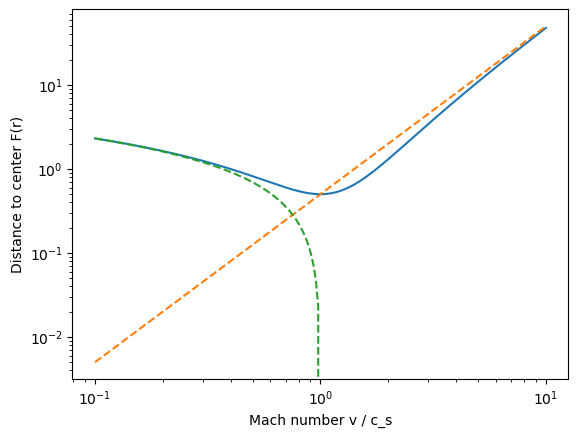

In [3]:
x = np.logspace(-1,1,201)
a = 1
y = (x**2 / 2 -  np.log(x))
y1 = x**2 / 2
y2 = -np.log(x)
plt.plot(x,y)
plt.plot(x,y1,linestyle="--")
plt.plot(x,y2,linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mach number v / c_s")
plt.ylabel("Distance to center F(r)")

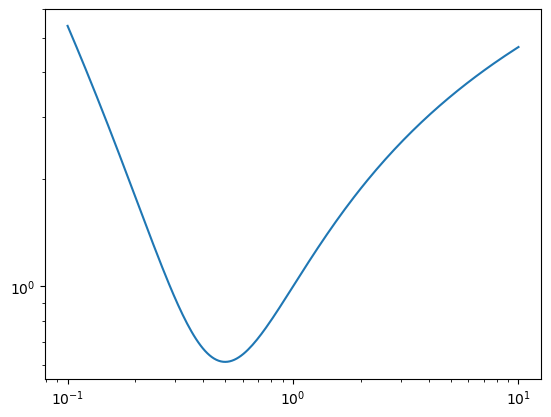

In [3]:
x = np.logspace(-1,1,201)
y = 1 / x + 2 * np.log(x)
plt.plot(x,y)
plt.xscale("log")
plt.yscale("log")

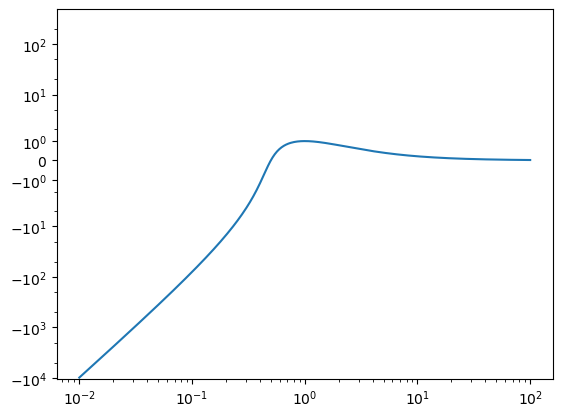

In [4]:
M = np.logspace(-2,2,400)
y = 2 / M - 1 / M**2
plt.plot(M, y)
plt.xscale("log")
plt.yscale("asinh")

In [23]:
np.max(y)

np.float64(0.9998683145272654)

In [5]:
"""
求解跨音速(transonic) wind 方程: v^2/2 - ln(v) = rh
方程 f(v) = v^2/2 - ln(v) 在 v=1 处取全局最小值 0.5,是临界(sonic)点。
  - rh < 0.5 : 无实数解
  - rh = 0.5 : 唯一解 v = 1 (临界点)
  - rh > 0.5 : 两个解,分属亚音速分支 (v<1) 和超音速分支 (v>1)

用 brentq 而非 fsolve:方程在每个分支上单调,给定明确区间比给单点初始猜测更稳健,
不会像 fsolve 那样在迭代中越界到 v<=0 导致 log 出现无效值。
"""

import numpy as np
from scipy.optimize import brentq

l = 201
x = np.logspace(-1, 1, l)
lmd = np.array([0.1, 1.12, 10])

# right.shape = (3, l)
right = 1 / x[None, :] + 2 * np.log(x[None, :]) - np.log(lmd[:, None])


def func(v, rh):
    return v**2 / 2 - np.log(v) - rh


u_sub = np.full((3, l), np.nan)  # 亚音速分支 v < 1
u_sup = np.full((3, l), np.nan)  # 超音速分支 v > 1

eps = 1e-8       # 区间下端点,避免 v=0 处 log 发散
v_max = 1e6      # 超音速分支区间上端点,按实际物理范围可调整

for i in range(3):
    for j in range(l):
        rh = right[i, j]
        if rh < 0.5:
            continue  # 无实数解,保留 nan
        u_sub[i, j] = brentq(func, eps, 1.0, args=(rh,))
        u_sup[i, j] = brentq(func, 1.0, v_max, args=(rh,))

print("subsonic branch sample:", u_sub[1, ::40])
print("supersonic branch sample:", u_sup[1, ::40])
print("valid points:", np.sum(~np.isnan(u_sub)), "/", u_sub.size)

subsonic branch sample: [0.00508486 0.35257724 0.78429277 0.24443952 0.05505368 0.0101347 ]
supersonic branch sample: [3.62471422 1.85652867 1.23261151 2.08488728 2.80432728 3.41144467]
valid points: 467 / 603


Text(0.5, 1.0, 'isothermal gas, 1/r potential')

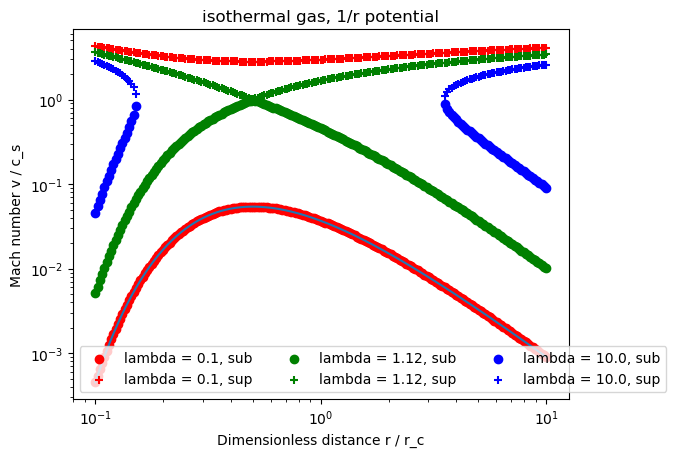

In [13]:
c_lst = ["red", "green", "blue"]
for i in range(3):
    plt.scatter(x, u_sub[i], label=f"lambda = {lmd[i]}, sub", c = c_lst[i])
    plt.scatter(x, u_sup[i], label=f"lambda = {lmd[i]}, sup", c = c_lst[i], marker="+")

y = 1e-1*np.exp(-1 / x) * x**-2
plt.plot(x,y)
plt.xscale("log")
plt.yscale("log")
plt.legend(ncol=3)
plt.xlabel("Dimensionless distance r / r_c")
plt.ylabel("Mach number v / c_s")
plt.title("isothermal gas, 1/r potential")

In [26]:
"""
多方(polytropic) Bondi 吸积问题求解 (Frank Shu, Ch.6)

方程:
    x^2 alpha v = lambda                                   (6.38)
    v^2/2 + H(alpha) - 1/x = 0                              (6.39)
    H(alpha) = gamma/(gamma-1) * (alpha^(gamma-1) - 1)      (6.41), gamma != 1

临界点 (声速点, 要求分子分母同时为零):
    x_c = (5 - 3*gamma) / (4*gamma)
    v_c = sqrt(1 / (2*x_c))
    alpha_c = (v_c^2 / gamma)^(1/(gamma-1))
    lambda_c = alpha_c * v_c * x_c^2

有效范围: gamma < 5/3 (gamma >= 5/3 时 x_c <= 0, 无有限临界半径)
"""

import numpy as np
from scipy.optimize import brentq

l = 201
x = np.logspace(-1, 1, l)
gamma = 2 / 3

# --- 临界点 & 临界吸积率 ---
x_c = (5 - 3 * gamma) / (4 * gamma)
v_c = (1 / (2 * x_c)) ** 0.5
alpha_c = (v_c**2 / gamma) ** (1 / (gamma - 1))
lmd_c = alpha_c * v_c * x_c**2

print(f"x_c={x_c:.4f}, v_c={v_c:.4f}, alpha_c={alpha_c:.4f}, lambda_c={lmd_c:.4f}")

lmd = np.array([0.1, 1, 10]) * lmd_c


def func(v, lmd, x):
    return v**2 / 2 + gamma / (gamma - 1) * ((lmd / x**2 / v) ** (gamma - 1) - 1) - 1 / x


u_sub = np.full((3, l), np.nan)  # 亚音速分支 v < 1 (更准确地说是 v < v_c)
u_sup = np.full((3, l), np.nan)  # 超音速分支 v > 1

eps = 1e-8      # 区间下端点, 避免 v=0 处发散
v_max = 1e6     # 超音速分支区间上端点, 可按实际物理范围调整

for i in range(3):
    for j in range(l):
        try:
            u_sub[i, j] = brentq(func, eps, 1.0, args=(lmd[i], x[j]))
        except ValueError:
            pass  # 该点无实数解, 或落在临界点附近区间不变号, 保留 nan
        try:
            u_sup[i, j] = brentq(func, 1.0, v_max, args=(lmd[i], x[j]))
        except ValueError:
            pass

print("subsonic branch sample:", u_sub[1, ::40])
print("supersonic branch sample:", u_sup[1, ::40])
print("valid subsonic points:", np.sum(~np.isnan(u_sub)), "/", u_sub.size)
print("valid supersonic points:", np.sum(~np.isnan(u_sup)), "/", u_sup.size)

x_c=1.1250, v_c=0.6667, alpha_c=3.3750, lambda_c=2.8477
subsonic branch sample: [       nan        nan 0.06493481 0.45070124 0.12165441 0.0244266 ]
supersonic branch sample: [4.12003463 2.3350896  1.16323712 1.11172607 2.4655049  4.15411931]
valid subsonic points: 252 / 603
valid supersonic points: 458 / 603


Text(0.5, 1.0, 'polytropic gas, 1/r potential')

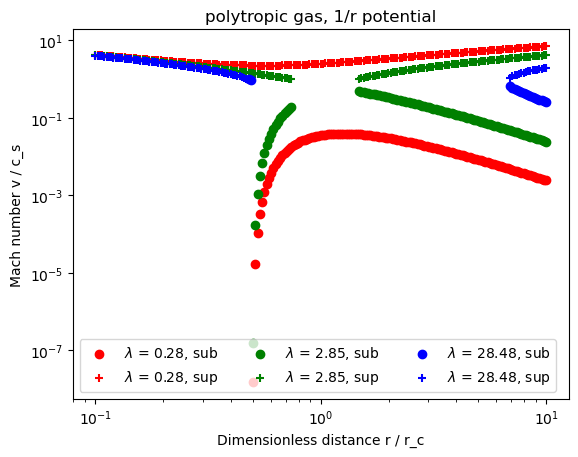

In [27]:
c_lst = ["red", "green", "blue"]
for i in range(3):
    plt.scatter(x, u_sub[i], label=f"$\lambda$ = {lmd[i]:.2f}, sub", c = c_lst[i])
    plt.scatter(x, u_sup[i], label=f"$\lambda$ = {lmd[i]:.2f}, sup", c = c_lst[i], marker="+")

plt.xscale("log")
plt.yscale("log")
plt.legend(ncol=3)
plt.xlabel("Dimensionless distance r / r_c")
plt.ylabel("Mach number v / c_s")
plt.title("polytropic gas, 1/r potential")

Text(0.5, 1.0, 'isothermal gas, log(r) potential')

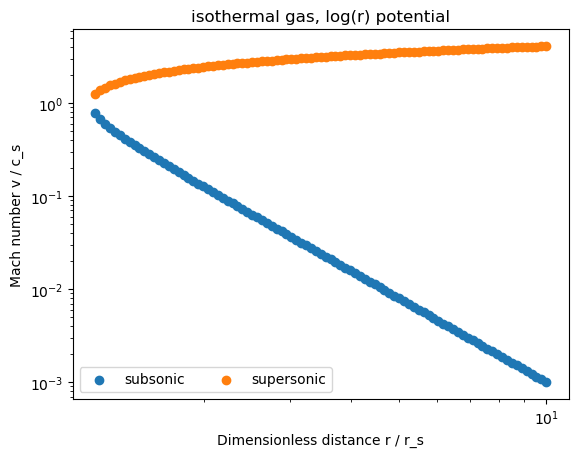

In [34]:
import numpy as np
from scipy.optimize import brentq

l = 201
x = np.logspace(-1, 1, l)
lmd = np.array([1,2,3])

def func(v, x, lmd):
    return v**2 / 2 - np.log(v) - 3 * np.log(x) + np.log(lmd)


u_sub = np.full(l, np.nan)  # 亚音速分支 v < 1
u_sup = np.full(l, np.nan)  # 超音速分支 v > 1

eps = 1e-8       # 区间下端点,避免 v=0 处 log 发散
v_max = 1e6      # 超音速分支区间上端点,按实际物理范围可调整


for i in range(l):
    try:
        u_sub[i] = brentq(func, eps, 1.0, args=(x[i],lmd[0]))
        u_sup[i] = brentq(func, 1.0, v_max, args=(x[i],lmd[0]))
    except:
        pass

c_lst = ["red", "green", "blue"]

plt.scatter(x, u_sub, label=f"subsonic")
plt.scatter(x, u_sup, label=f"supersonic")

plt.xscale("log")
plt.yscale("log")
plt.legend(ncol=3)
plt.xlabel("Dimensionless distance r / r_s")
plt.ylabel("Mach number v / c_s")
plt.title("isothermal gas, log(r) potential")

In [29]:
np.full(3, np.nan)

array([nan, nan, nan])

In [3]:
361 * 321 * 100 / 8 /1024 / 1024

1.3814091682434082

In [15]:
4 / np.e**2

0.5413411329464508